In [1]:
import polars as pl
import duckdb
import os
from pathlib import Path
from typing import Tuple, List, Dict, Union

In [3]:
DATA_DIR=Path("../../Sepsis-data/data/raw_data_phase2_v2")
os.listdir(DATA_DIR)

['Lab Results - 3.9.26.csv',
 'Flowsheet - 3.9.26.csv',
 'Procedure Orders - 3.9.26.csv',
 'Diagnoses - 3.9.26.csv',
 'Flowsheet SBP - 3.9.26.csv',
 'Encounter Table with Baseline Values - Mar 2025 - Feb 2026 - 3.25.26.csv',
 'Med Admin - 3.9.26.csv',
 'Encounter Table with Baseline Values - Mar 2025 - Feb 2026.csv',
 'Flowsheet - 3.24.26.csv']

In [4]:
lab_res = pl.read_csv(DATA_DIR/Path("Lab Results - 3.9.26.csv"), infer_schema=False, null_values=['Null', "NULL", 'null'])
flowsheets = pl.read_csv(DATA_DIR/Path("Flowsheet - 3.24.26.csv"), infer_schema=False, null_values=['Null', "NULL", 'null'])
# flowsheets_sbp = pl.read_csv(DATA_DIR/Path("Flowsheet SBP - 3.9.26.csv"), infer_schema=False, null_values=['Null', "NULL", 'null'])
med_admin = pl.read_csv(DATA_DIR/Path("Med Admin - 3.9.26.csv"), infer_schema=False, null_values=['Null', "NULL", 'null'])
procedures = pl.read_csv(DATA_DIR/Path("Procedure Orders - 3.9.26.csv"), infer_schema=False, null_values=['Null', "NULL", 'null'])
baseline = pl.read_csv(DATA_DIR/Path("Encounter Table with Baseline Values - Mar 2025 - Feb 2026 - 3.25.26.csv"), infer_schema=False, null_values=['Null', "NULL", 'null'])
diagnosis = pl.read_csv(DATA_DIR/Path("Diagnoses - 3.9.26.csv"), infer_schema=False, null_values=['Null', "NULL", 'null'])

In [5]:
def cast_cols(df: pl.DataFrame):
    
    cast_expr = [pl.col(c).cast(pl.Float64) for c in df.columns if c.startswith('Baseline_')]

    if df.schema['EncounterEpicCsn'] == pl.Utf8:
        cast_expr.append(
            pl.col("EncounterEpicCsn").cast(pl.Int64)
        )

    if 'PrimaryMrn' in df.schema and df.schema['PrimaryMrn'] == pl.Utf8:
        cast_expr.append(
            pl.col("PrimaryMrn").cast(pl.Int64)
        )

    if 'Death_Flag' in df.schema and df.schema['Death_Flag'] == pl.Utf8:
        cast_expr.append(
            pl.col("Death_Flag").cast(pl.Int64)
        )


    if 'Event_DateTime' in df.schema and df.schema['Event_DateTime'] == pl.Utf8:
        cast_expr.append(
            pl.col("Event_DateTime").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S%.f"),
        )

    if 'Arrival_Instant' in df.schema and df.schema['Arrival_Instant'] == pl.Utf8:
        cast_expr.append(
            pl.col("Arrival_Instant").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S%.f"),
        )

    if 'FirstAdmissionOrderInstant' in df.schema and df.schema['FirstAdmissionOrderInstant'] == pl.Utf8:
        cast_expr.append(
            pl.col("FirstAdmissionOrderInstant").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S%.f"),
        )

    if 'InpatientAdmissionInstant' in df.schema and df.schema['InpatientAdmissionInstant'] == pl.Utf8:
        cast_expr.append(
            pl.col("InpatientAdmissionInstant").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S%.f"),
        )

    if 'AdmissionDateValue' in df.schema and df.schema['AdmissionDateValue'] == pl.Utf8:
        cast_expr.append(
            pl.col("AdmissionDateValue").str.strptime(pl.Datetime, "%Y-%m-%d"),
        )

    if 'DischargeDateValue' in df.schema and df.schema['DischargeDateValue'] == pl.Utf8:
        cast_expr.append(
            pl.col("DischargeDateValue").str.strptime(pl.Datetime, "%Y-%m-%d"),
        )


    if 'NumericValue' in df.schema and df.schema['NumericValue'] == pl.Utf8:
        cast_expr.append(
            pl.col("NumericValue").cast(pl.Float64)
        )
    
    return df.with_columns(
        cast_expr
    )

In [6]:
lab_res = cast_cols(lab_res)
flowsheets = cast_cols(flowsheets)
# flowsheets_sbp = cast_cols(flowsheets_sbp)
med_admin = cast_cols(med_admin)
procedures = cast_cols(procedures)
baseline = cast_cols(baseline)
diagnosis = cast_cols(diagnosis)

In [7]:
[c for c in baseline.columns if c.startswith('Baseline_')]

['Baseline_SBP',
 'Baseline_RespiratoryRate',
 'Baseline_PulseRate',
 'Baseline_Creatinine',
 'Baseline_Platelets',
 'Baseline_Bilirubin',
 'Baseline_eGFR',
 'Baseline_WBC']

In [8]:
df_all = pl.concat([
    lab_res, procedures, med_admin, flowsheets, diagnosis
], how='vertical')

In [9]:
df_all = df_all.join(
    baseline,
    on='EncounterEpicCsn',
    how='outer'
)

df_all = df_all.unique()
df_all = df_all.filter(
    (pl.col("EncounterEpicCsn").is_not_null()) & (pl.col("Event_DateTime").is_not_null()) 
)

/tmp/ipykernel_3209209/1485415252.py:1: DeprecationWarning: use of `how='outer'` should be replaced with `how='full'`.
(Deprecated in version 0.20.29)
  df_all = df_all.join(


In [10]:
df_all.columns

['EncounterEpicCsn',
 'Event_DateTime',
 'Type',
 'Event_Grouper',
 'Event_Name',
 'NumericValue',
 'Value',
 'Flag',
 'PrimaryMrn',
 'EncounterEpicCsn_right',
 'AdmissionDateValue',
 'DischargeDateValue',
 'Arrival_Instant',
 'InpatientAdmissionInstant',
 'Admitted_from_ED',
 'PatientClass',
 'InpatientAdmissionPatientClass',
 'HospitalService',
 'AdmittingDepartment',
 'DischargeDepartment',
 'AdmissionType',
 'AdmissionSource',
 'AdmissionOrigin',
 'PrincipalProblem',
 'PrimaryCodedDiagnosis',
 'PrimaryCodedProcedureKey',
 'Death_Flag',
 'Original_POA_Condition',
 'Sepsis_Category',
 'Baseline_SBP',
 'Baseline_RespiratoryRate',
 'Baseline_PulseRate',
 'Baseline_Creatinine',
 'Baseline_Platelets',
 'Baseline_Bilirubin',
 'Baseline_eGFR',
 'Baseline_WBC',
 'Suspected_Infection_Time',
 'Suspected_Infection_Criteria_Met']

In [11]:
baseline.columns

['PrimaryMrn',
 'EncounterEpicCsn',
 'AdmissionDateValue',
 'DischargeDateValue',
 'Arrival_Instant',
 'InpatientAdmissionInstant',
 'Admitted_from_ED',
 'PatientClass',
 'InpatientAdmissionPatientClass',
 'HospitalService',
 'AdmittingDepartment',
 'DischargeDepartment',
 'AdmissionType',
 'AdmissionSource',
 'AdmissionOrigin',
 'PrincipalProblem',
 'PrimaryCodedDiagnosis',
 'PrimaryCodedProcedureKey',
 'Death_Flag',
 'Original_POA_Condition',
 'Sepsis_Category',
 'Baseline_SBP',
 'Baseline_RespiratoryRate',
 'Baseline_PulseRate',
 'Baseline_Creatinine',
 'Baseline_Platelets',
 'Baseline_Bilirubin',
 'Baseline_eGFR',
 'Baseline_WBC',
 'Suspected_Infection_Time',
 'Suspected_Infection_Criteria_Met']

In [25]:
df_all.filter(
    pl.col("Event_Grouper") == "Phenylephrine"
)['Event_Name'].unique().to_list()

['PHENYLEPHRINE (PF) 20 MG/250 ML (80 MCG/ML) IN 0.9% SODIUM CHLORIDE IV',
 'PHENYLEPHRINE 40 MG/250 ML (160 MCG/ML) IN 0.9 % SODIUM CHLORIDE IV',
 'PHENYLEPHRINE 1 MG/10 ML (100 MCG/ML) IN 0.9 % SOD.CHLORIDE IV SYRINGE',
 'PHENYLEPHRINE 10 MG/ML INJECTION']

In [17]:
"""
IV antibiotics administered and blood culture ordered
Blood culture 72 hours before or 24 hours after IV antibiotics administered
"""
df_iv = df_all.filter(
    pl.col("Type")=="IV Antibiotics"
).select("EncounterEpicCsn", "Event_DateTime", "Event_Name").rename({"Event_DateTime": "iv_dt", "Event_Name": "iv_name"})

df_culture = df_all.filter(
    pl.col("Event_Grouper")=="Blood Culture Order"
).select("EncounterEpicCsn", "Event_DateTime", "Event_Name").rename({"Event_DateTime": "culture_dt", "Event_Name": "culture_name"})

df_forward = df_iv.join_asof(
    df_culture,
    left_on="iv_dt",
    right_on="culture_dt",
    by="EncounterEpicCsn",
    strategy="forward",
    tolerance="24h"
)

df_backward = df_iv.join_asof(
    df_culture,
    left_on="iv_dt",
    right_on="culture_dt",
    by="EncounterEpicCsn",
    strategy="backward",
    tolerance="72h"
)

df_infection_detection = pl.concat([df_backward, df_forward], how="vertical").unique()

df_infect = df_infection_detection.group_by("EncounterEpicCsn").agg(pl.col("iv_dt").min()).join(df_infection_detection.group_by("EncounterEpicCsn").agg(pl.col("culture_dt").min()), on="EncounterEpicCsn").with_columns(
    pl.min_horizontal(["iv_dt", "culture_dt"]).alias("first_ev_time")
)


/tmp/ipykernel_4011850/51802536.py:13: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_forward = df_iv.join_asof(
/tmp/ipykernel_4011850/51802536.py:22: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  df_backward = df_iv.join_asof(


In [18]:
"""
Two blood culture orders within 6 hours of lactate order
"""
df_lactate = df_all.filter(
    pl.col("Event_Grouper") == "Lactate"
)

df_lac_cult = duckdb.sql(
    """
    SELECT cul.EncounterEpicCsn, cul.culture_dt AS cul_dt, lac.Event_DateTime AS lac_dt
    FROM df_culture as cul
    LEFT JOIN df_lactate lac
    ON lac.EncounterEpicCsn=cul.EncounterEpicCsn
    AND lac.Event_DateTime >= cul.culture_dt - INTERVAL '6 hours'
    AND lac.Event_DateTime <= cul.culture_dt + INTERVAL '6 hours'
    """
).pl()

df_lac_cult

EncounterEpicCsn,cul_dt,lac_dt
i64,datetime[μs],datetime[μs]
727790834,2025-05-20 10:11:00,2025-05-20 11:12:00
746515486,2026-02-14 22:32:00,2026-02-14 23:45:00
739130287,2025-11-05 11:12:00,2025-11-05 15:54:00
738207629,2025-10-14 23:34:00,2025-10-14 23:42:00
722523701,2025-03-03 15:36:00,2025-03-03 16:21:00
…,…,…
737206914,2026-01-29 11:35:00,2026-01-29 09:55:00
737206914,2025-12-19 19:42:00,2025-12-20 01:05:00
737206914,2026-01-29 11:35:00,2026-01-29 12:39:00


In [19]:
"""
Suspected infection flowsheet with answer yes exists
"""
df_suspected_infection_grouper = df_all.filter(
    (pl.col("Event_Grouper") == "Suspected Infection")&
    (pl.col("Value") == "Yes")
)

In [20]:
"""
Code sepsis order exists
"""

df_code_sepsis_page = df_all.filter(pl.col("Event_Grouper") == "Code Sepsis Page")

In [21]:
"""
Temp abnormal flag (temp high or temp low)
"""
df_temp_abnormal = df_all.filter(
    (pl.col("Event_Grouper") == "Temperature")&
    (
        (pl.col("NumericValue") < 96.8)|
        (pl.col("NumericValue") > 100.4)
    )
).select(
    "EncounterEpicCsn", "Event_DateTime","Event_Name","Value"
).with_columns(
    pl.lit(1).alias("Temp_Abnormal_Flag")
)
df_temp_abnormal

EncounterEpicCsn,Event_DateTime,Event_Name,Value,Temp_Abnormal_Flag
i64,datetime[μs],str,str,i32
729594194,2025-06-20 11:51:00,"""TEMPERATURE""","""96.7""",1
739527021,2026-02-20 01:00:00,"""TEMPERATURE""","""96.3""",1
741953942,2025-12-05 15:25:00,"""TEMPERATURE""","""100.8""",1
730903806,2025-07-08 11:54:00,"""TEMPERATURE""","""101.6""",1
727174788,2025-05-16 07:00:00,"""TEMPERATURE""","""96.4""",1
…,…,…,…,…
740790385,2025-11-21 19:00:00,"""TEMPERATURE""","""96.3""",1
729495031,2025-06-26 15:00:00,"""TEMPERATURE""","""96.6""",1
732593740,2025-08-15 19:47:21,"""TEMPERATURE""","""100.8""",1


In [22]:
"""
Heart rate abnormal flag ( pulse > 90)
"""
df_pulse_abnormal = df_all.filter(
    (pl.col("Event_Grouper") == "Pulse")&
    (
        (pl.col("NumericValue") > 90)
    )
).select(
    "EncounterEpicCsn", "Event_DateTime","Event_Name","Value"
).with_columns(
    pl.lit(1).alias("HR_High_Flag")
)
df_pulse_abnormal

EncounterEpicCsn,Event_DateTime,Event_Name,Value,HR_High_Flag
i64,datetime[μs],str,str,i32
735413590,2025-09-13 07:28:00,"""PULSE""","""103""",1
720282087,2025-03-04 10:30:00,"""PULSE""","""93""",1
731688402,2025-08-18 03:44:00,"""PULSE""","""127""",1
734530177,2025-09-01 08:50:00,"""UTSW R SPO2 PULSE RATE""","""115""",1
720117699,2025-02-06 00:15:00,"""PULSE""","""97""",1
…,…,…,…,…
723376913,2025-03-20 00:12:00,"""PULSE""","""111""",1
741343987,2025-12-02 16:45:00,"""PULSE""","""91""",1
742196501,2025-12-16 23:00:00,"""PULSE""","""128""",1


In [23]:
"""
Respiratory rate high flag (Respirations > 20)
"""

df_resp_abnormal = df_all.filter(
    (pl.col("Event_Grouper")=="Respirations")&
    (pl.col("NumericValue")>20)
).select(
    "EncounterEpicCsn", "Event_DateTime","Event_Name","Value"
).with_columns(
    pl.lit(1).alias("Resp_Rate_High_Flag")
)
df_resp_abnormal

EncounterEpicCsn,Event_DateTime,Event_Name,Value,Resp_Rate_High_Flag
i64,datetime[μs],str,str,i32
727130802,2025-05-10 13:57:00,"""RESPIRATIONS""","""26""",1
726154894,2025-05-10 15:00:00,"""RESPIRATIONS""","""22""",1
725135485,2025-04-24 17:45:00,"""RESPIRATIONS""","""30""",1
728958778,2025-06-09 18:30:00,"""RESPIRATIONS""","""23""",1
736786912,2025-11-16 16:30:00,"""RESPIRATIONS""","""24""",1
…,…,…,…,…
735300844,2025-09-12 19:13:00,"""RESPIRATIONS""","""35""",1
728503997,2025-07-25 20:00:00,"""RESPIRATIONS""","""22""",1
729873597,2025-06-27 18:15:00,"""RESPIRATIONS""","""24""",1


In [24]:
df_wbc_abnormal = df_all.filter(
    (pl.col("Event_Grouper") == "WBC")&
    (
        (pl.col("NumericValue") > 12)|
        (pl.col("NumericValue") < 4)
    )
).select(
    "EncounterEpicCsn", "Event_DateTime","Event_Name","Value"
).with_columns(
    pl.lit(1).alias("WBC_Abnormal_Flag")
)
df_wbc_abnormal

EncounterEpicCsn,Event_DateTime,Event_Name,Value,WBC_Abnormal_Flag
i64,datetime[μs],str,str,i32
734067060,2025-09-24 21:33:00,"""WBC""","""15.48""",1
736836690,2025-10-31 18:56:00,"""WBC""","""14.65""",1
724429565,2025-04-18 09:28:00,"""WBC""","""18.30""",1
728988647,2025-06-24 00:16:00,"""WBC""","""12.28""",1
722791465,2025-04-24 06:33:00,"""WBC""","""18.88""",1
…,…,…,…,…
738627631,2025-11-01 04:18:00,"""WBC""","""1.18""",1
733908128,2025-09-07 06:36:00,"""WBC""","""12.20""",1
732402103,2025-09-13 04:42:00,"""WBC""","""29.24""",1


In [16]:
df_wbc_joined = df_all.join(
    df_wbc_abnormal,
    on=["EncounterEpicCsn", "Event_DateTime", "Event_Name"],
    how='left'
).filter(pl.col("WBC_Abnormal_Flag").is_not_null())

In [17]:
df_wbc_joined.select("EncounterEpicCsn", 'Event_DateTime', "Event_Name", "WBC_Abnormal_Flag").sort(by=['EncounterEpicCsn', "Event_DateTime"])

EncounterEpicCsn,Event_DateTime,Event_Name,WBC_Abnormal_Flag
i64,datetime[μs],str,i32
699476058,2024-04-30 17:41:00,"""WBC""",1
699476058,2024-05-02 03:28:00,"""WBC""",1
699476058,2024-05-02 10:20:00,"""WBC""",1
699476058,2024-05-02 16:30:00,"""WBC""",1
699476058,2024-05-02 22:15:00,"""WBC""",1
…,…,…,…
747232821,2026-02-24 21:18:00,"""WBC""",1
747232821,2026-02-25 05:08:00,"""WBC""",1
747232821,2026-02-26 10:36:00,"""WBC""",1


In [18]:
df_wbc_abnormal.sort(by=['EncounterEpicCsn', "Event_DateTime"]).join(df_wbc_joined, on=["EncounterEpicCsn", "Event_DateTime", "Event_Name"], how='anti')

EncounterEpicCsn,Event_DateTime,Event_Name,Value,WBC_Abnormal_Flag
i64,datetime[μs],str,str,i32


In [19]:
pl.struct(df_wbc_abnormal.columns)

<Expr ['as_struct("EncounterEpicCsn", …'] at 0x7F1215329750>

In [20]:
df_all_abnormal_flags = df_all.join(
   df_wbc_abnormal,
   on=["EncounterEpicCsn", "Event_DateTime", "Event_Name"],
   how='left'
).drop([ "Value_right",  ]).join(
   df_temp_abnormal,
   on=["EncounterEpicCsn", "Event_DateTime", "Event_Name"],
   how='left'
).drop([ "Value_right",  ]).join(
   df_resp_abnormal,
   on=["EncounterEpicCsn", "Event_DateTime", "Event_Name"],
   how='left'
).drop([ "Value_right",  ]).join(
   df_pulse_abnormal,
   on=["EncounterEpicCsn", "Event_DateTime", "Event_Name"],
   how='left'
).drop(['Value_right'])

df_all_abnormal_flags = df_all_abnormal_flags.with_columns(
   [pl.col(c).fill_null(0) for c in df_all_abnormal_flags.columns if c.endswith("Abnormal_Flag") or c.endswith("High_Flag")]
)

df_all_abnormal_flags.select([c for c in df_all_abnormal_flags.columns if c.endswith("_Flag")]).sum()

Death_Flag,WBC_Abnormal_Flag,Temp_Abnormal_Flag,Resp_Rate_High_Flag,HR_High_Flag
i64,i32,i32,i32,i32
2322421,33015,26906,423222,787868


In [21]:
df_all_abnormal_flags = df_all_abnormal_flags.with_columns(
    sirs_score=pl.col("WBC_Abnormal_Flag")+pl.col("Temp_Abnormal_Flag")+pl.col("Resp_Rate_High_Flag")+pl.col("HR_High_Flag")
)

In [27]:
reference = df_all.select("EncounterEpicCsn", "Event_DateTime").unique().sort(by=["EncounterEpicCsn", "Event_DateTime"])
df_temp = df_all.filter(
    pl.col("Event_Grouper") == "Temperature"
).select("EncounterEpicCsn", "Event_DateTime", "NumericValue")\
.sort(by=["EncounterEpicCsn", "Event_DateTime"])\
.with_columns(
    pl.col("NumericValue").forward_fill().over("EncounterEpicCsn").backward_fill().over("EncounterEpicCsn").fill_null(98)
).with_columns(
    pl.when(
        pl.col("NumericValue")<97
	).then(1).when(
		pl.col("NumericValue")>100.4
	).then(1).otherwise(0).alias("Temp_Abnormal_Flag")
)
temp_ref = duckdb.sql(
	"""
	SELECT ref.EncounterEpicCsn, ref.Event_DateTime, temp.NumericValue AS Temp_Value, temp.Temp_Abnormal_Flag
	FROM reference AS ref
	LEFT JOIN df_temp AS temp
	ON ref.EncounterEpicCsn = temp.EncounterEpicCsn
	AND ref.Event_DateTime >= temp.Event_DateTime
	AND ref.Event_DateTime <= temp.Event_DateTime + INTERVAL '1 day'
	"""
).pl()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [39]:
df_wbc = df_all.filter(
    pl.col("Event_Grouper") == "WBC"
).select("EncounterEpicCsn", "Event_DateTime", "NumericValue")\
.sort(by=["EncounterEpicCsn", "Event_DateTime"])\
.with_columns(
    pl.col("NumericValue").forward_fill().over("EncounterEpicCsn").backward_fill().over("EncounterEpicCsn").fill_null(98)
).with_columns(
    pl.when(
        (pl.col("NumericValue")<4)|(pl.col("NumericValue")>12)
	).then(1).otherwise(0).alias("WBC_Abnormal_Flag")
)

In [33]:
df_wbc = df_all.filter(
    pl.col("Event_Grouper") == "WBC"
).select("EncounterEpicCsn", "Event_DateTime", "NumericValue")

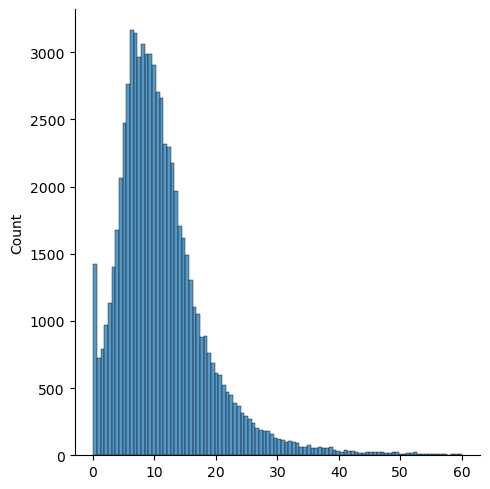

In [38]:
import seaborn as sns
sns.displot(df_wbc.select("NumericValue").filter(pl.col("NumericValue").is_not_null()&(pl.col("NumericValue")<60)).to_numpy().flatten(), bins=100)

In [31]:
df_wbc

EncounterEpicCsn,Event_DateTime,NumericValue,WBC_Abnormal_Flag
i64,datetime[μs],f64,i32
699476058,2024-04-30 16:08:00,11.0,0
699476058,2024-04-30 17:41:00,14.53,1
699476058,2024-04-30 19:56:00,11.07,0
699476058,2024-04-30 22:59:00,10.32,0
699476058,2024-05-01 03:18:00,10.47,0
…,…,…,…
747311714,2026-02-26 15:33:00,10.26,0
747311714,2026-02-26 17:29:00,6.95,0
747311714,2026-02-26 23:51:00,5.52,0


In [29]:
reference

EncounterEpicCsn,Event_DateTime
i64,datetime[μs]
699476058,2024-03-06 03:09:37.020
699476058,2024-04-30 03:39:43.660
699476058,2024-04-30 06:15:00
699476058,2024-04-30 06:25:00
699476058,2024-04-30 07:05:00
…,…
747311714,2026-02-28 02:15:39.777
747311714,2026-03-01 02:54:35.660
747311714,2026-03-03 02:39:48.620


In [28]:
temp_ref

EncounterEpicCsn,Event_DateTime,Temp_Value,Temp_Abnormal_Flag
i64,datetime[μs],f64,i32
744529729,2026-01-30 11:45:35,98.8,0
744534628,2026-01-19 07:24:35,98.4,0
744534628,2026-01-19 07:25:00,98.4,0
744534628,2026-01-19 07:29:00,98.4,0
744534628,2026-01-19 08:00:00,98.4,0
…,…,…,…
714445951,2024-12-05 11:18:00,97.9,0
714445951,2024-12-05 12:00:00,97.9,0
714445951,2024-12-05 10:50:00,98.2,0


In [1]:
df_all.columns

NameError: name 'df_all' is not defined

In [ ]:
df_all.filter(pl.col("Event_Grouper")=="Temperature")\
.select("EncounterEpicCsn", "Event_DateTime", "NumericValue").sort(by=["EncounterEpicCsn", "Event_DateTime"])\
.with_columns(
    pl.col("NumericValue").fill_null(strategy="forward").over("EncounterEpicCsn").fill_null(strategy="backward").over("EncounterEpicCsn").fill_null(97)
).rolling(
    index_column="Event_DateTime",
	group_by="EncounterEpicCsn",
    period="24h",
    closed="right"
).agg(
    pl.col("NumericValue").max().alias("Temp_24h_Max"),
    pl.col("NumericValue").min().alias("Temp_24h_Min"),
    pl.col("NumericValue").last().alias("Temp")
)


EncounterEpicCsn,Event_DateTime,Temp_24h_Max,Temp_24h_Min,NumericValue
i64,datetime[μs],f64,f64,list[f64]
699476058,2024-04-30 06:15:00,97.5,97.5,[97.5]
699476058,2024-04-30 22:00:00,97.5,96.7,"[97.5, 96.7]"
699476058,2024-04-30 22:40:00,98.4,96.7,"[97.5, 96.7, 98.4]"
699476058,2024-04-30 22:50:00,98.4,96.7,"[97.5, 96.7, … 98.4]"
699476058,2024-04-30 23:00:00,98.4,96.7,"[97.5, 96.7, … 98.4]"
…,…,…,…,…
747311714,2026-02-27 01:00:00,98.5,95.9,"[96.6, 95.9, … 98.5]"
747311714,2026-02-27 03:07:00,99.1,95.9,"[95.9, 97.0, … 99.1]"
747311714,2026-02-27 05:00:00,99.4,95.9,"[95.9, 97.0, … 99.4]"


In [56]:
df_all.filter(pl.col("Event_Grouper") == "Temperature").pivot(
    index=["EncounterEpicCsn", "Event_DateTime"],
    on="Event_Grouper",
	values="NumericValue"
).sort(by=["EncounterEpicCsn", "Event_DateTime"])\
.with_columns(pl.col("Temperature").fill_null(strategy="forward").over("EncounterEpicCsn").fill_null(strategy="backward").over("EncounterEpicCsn").fill_null(97))\
.rolling(
    index_column="Event_DateTime",
	group_by="EncounterEpicCsn",
    period="24h"
).agg(
	pl.col("Temperature").last(),
    pl.col("Temperature").max().alias("Temp_Max_24h"),
	pl.col("Temperature").min().alias("Temp_Min_24h"),
)


EncounterEpicCsn,Event_DateTime,Temperature,Temp_Max_24h,Temp_Min_24h
i64,datetime[μs],f64,f64,f64
699476058,2024-04-30 06:15:00,97.5,97.5,97.5
699476058,2024-04-30 22:00:00,96.7,97.5,96.7
699476058,2024-04-30 22:40:00,98.4,98.4,96.7
699476058,2024-04-30 22:50:00,98.4,98.4,96.7
699476058,2024-04-30 23:00:00,98.4,98.4,96.7
…,…,…,…,…
747311714,2026-02-27 01:00:00,98.5,98.5,95.9
747311714,2026-02-27 03:07:00,99.1,99.1,95.9
747311714,2026-02-27 05:00:00,99.4,99.4,95.9


In [57]:
df_all.filter(pl.col("Event_Grouper") == "Temperature").pivot(
    index=["EncounterEpicCsn", "Event_DateTime"],
    columns="Event_Grouper",
	values="NumericValue"
).sort(by=["EncounterEpicCsn", "Event_DateTime"])

/tmp/ipykernel_3539890/527135961.py:1: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  df_all.filter(pl.col("Event_Grouper") == "Temperature").pivot(


EncounterEpicCsn,Event_DateTime,Temperature
i64,datetime[μs],f64
699476058,2024-04-30 06:15:00,97.5
699476058,2024-04-30 22:00:00,96.7
699476058,2024-04-30 22:40:00,98.4
699476058,2024-04-30 22:50:00,98.4
699476058,2024-04-30 23:00:00,98.4
…,…,…
747311714,2026-02-27 01:00:00,98.5
747311714,2026-02-27 03:07:00,99.1
747311714,2026-02-27 05:00:00,99.4


In [20]:
df_all.filter(pl.col("Event_Grouper") == "Temperature").pivot(
    index=["EncounterEpicCsn", "Event_DateTime"],
    columns="Event_Grouper",
	values="NumericValue"
).sort(by=["EncounterEpicCsn", "Event_DateTime"]).join(
    df_all.group_by("EncounterEpicCsn").agg([pl.col(c).first() for c in df_all.columns if c.startswith("Baseline_")]),
    on="EncounterEpicCsn",
	how="left"
)

/tmp/ipykernel_3539890/3362577923.py:1: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  df_all.filter(pl.col("Event_Grouper") == "Temperature").pivot(


EncounterEpicCsn,Event_DateTime,Temperature,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_WBC
i64,datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64
699476058,2024-04-30 06:15:00,97.5,126.0,15.0,97.0,1.27,298.5,0.7,8.765
699476058,2024-04-30 22:00:00,96.7,126.0,15.0,97.0,1.27,298.5,0.7,8.765
699476058,2024-04-30 22:40:00,98.4,126.0,15.0,97.0,1.27,298.5,0.7,8.765
699476058,2024-04-30 22:50:00,98.4,126.0,15.0,97.0,1.27,298.5,0.7,8.765
699476058,2024-04-30 23:00:00,98.4,126.0,15.0,97.0,1.27,298.5,0.7,8.765
…,…,…,…,…,…,…,…,…,…
747311714,2026-02-27 01:00:00,98.5,null,null,null,null,null,null,null
747311714,2026-02-27 03:07:00,99.1,null,null,null,null,null,null,null
747311714,2026-02-27 05:00:00,99.4,null,null,null,null,null,null,null


In [ ]:
df_all.rolling(index_column="Event_DateTime", by="EncounterEpicCsn", period="24h").agg(
    pl.col("Value").last().alias("max_sirs_24h")
)

/tmp/ipykernel_3536636/580858169.py:1: DeprecationWarning: the argument `by` for `DataFrame.rolling` is deprecated. It was renamed to `group_by` in version 0.20.14.
  df_all.rolling(index_column="Event_DateTime", by="EncounterEpicCsn", period="24h").agg(


ComputeError: null values in `rolling` not supported, fill nulls.

In [23]:
def suspected_infection_events(df_all:pl.DataFrame):
    return df_all.filter(
        (pl.col("Type")=="IV Antibiotics") |
        (pl.col("Event_Grouper").is_in(["Code Sepsis Page", "Blood Culture Order", "Lactate"])) | 
		(
			(pl.col("Event_Grouper")=='Suspected Infection')&
			(pl.col("Value") == "Yes")
		)
	)

def sirs_events(df_all:pl.DataFrame):
    return df_all.filter(
        pl.col("Event_Grouper").is_in(["WBC", "Temperature", "Pulse", "Respirations"])
	)

def organ_dysfunction_events(df_all: pl.DataFrame):
    return df_all.filter(
        pl.col("Event_Grouper").is_in([
            "Creatinine", "Bilirubin", "Platelets", "Lactate", "INR", "APTT",
            "Vent on Documentation", "Vent off Documentation",
            "Arterial Blood Pressure Mean", "eGFR",
            "O2 Delivery High-Flow Nasal Cannula",
            "O2 Delivery Mechanical Ventilation",
            "Glascow Coma Score",
        ])
    )

def septic_shock_events(df_all: pl.DataFrame):
    return df_all.filter(
        pl.col("Event_Grouper").is_in([
            "Lactate", "Systolic Blood Pressure",
            "Norepinephrine", "Vasopressin", "Epinephrine", "Phenylephrine",
        ])
    )



def build_reference_table(df_all: pl.DataFrame) -> pl.DataFrame:
    """
    Combine all 4 event categories, then deduplicate to get
    one row per (EncounterEpicCsn, Event_DateTime).
    
    This is the 'grain' of our calculation — every potential
    transition point for sepsis severity.
    """
    # Stack all relevant events (some rows will appear in multiple
    # categories, e.g. Lactate — that's fine, we deduplicate below)
    relevant_events = pl.concat([
        suspected_infection_events(df_all).with_columns(pl.lit("suspected_infection").alias("sep-event")),
        sirs_events(df_all).with_columns(pl.lit("sirs_events").alias("sep-event")),
        organ_dysfunction_events(df_all).with_columns(pl.lit("organ_dysf").alias("sep-event")),
        septic_shock_events(df_all).with_columns(pl.lit("septic_shock").alias("sep-event")),
    ])

    # Deduplicate to get the reference grain
    reference = (
        relevant_events
        .select("EncounterEpicCsn", "Event_DateTime", "sep-event")
        .unique()
        .sort("EncounterEpicCsn", "Event_DateTime")
    )

    return reference

def rolling_agg(
    reference: pl.DataFrame,
    df_all: pl.DataFrame,
    event_grouper: str | list[str],
    agg_col_name: str,
    agg_func: str = "max",  # "max", "min", or "last"
    lookback_hours: float = 24.0,
) -> pl.DataFrame:
    """
    For each reference row, look back `lookback_hours` into df_all
    for events matching `event_grouper`, and compute the aggregate
    of NumericValue.

    Parameters
    ----------
    reference : the (CSN, datetime) reference table
    df_all : the full events table
    event_grouper : which Event_Grouper(s) to look for
    agg_col_name : name of the output column
    agg_func : "max", "min", or "last"
    lookback_hours : how far back to look

    Returns
    -------
    reference table with one new column added
    """
    if isinstance(event_grouper, str):
        event_grouper = [event_grouper]

    # Step 1: Extract only the events we care about
    if event_grouper[0] == "Systolic Blood Pressure":
        events_sub = (
                df_all.filter(pl.col("Event_Grouper") == 'Blood Pressure').with_columns(
                pl.col("Value").str.split('/').list.first().cast(pl.Int64).alias('sys')
            ).select(
                pl.col("EncounterEpicCsn"),
                pl.col("Event_DateTime").alias("evt_dt"),
                pl.col("sys").alias("evt_val"),
            )
                      )
    else:
        events_sub = (
            df_all
            .filter(
                pl.col("Event_Grouper").is_in(event_grouper)
                & pl.col("NumericValue").is_not_null()
            )
            .select(
                pl.col("EncounterEpicCsn"),
                pl.col("Event_DateTime").alias("evt_dt"),
                pl.col("NumericValue").alias("evt_val"),
            )
        )

    # Step 2: Join reference × events on CSN
    # joined = reference.join(events_sub, on="EncounterEpicCsn", how="left")

    # # Step 3: Filter to events within the lookback window
    # #   evt_dt <= Event_DateTime  (happened at or before reference time)
    # #   evt_dt > Event_DateTime - lookback
    # lookback = pl.duration(hours=lookback_hours)
    # joined = joined.filter(
    #     (pl.col("evt_dt") <= pl.col("Event_DateTime"))
    #     & (pl.col("evt_dt") >= pl.col("Event_DateTime") - lookback)
    # )

    # joined = duckdb.sql("""
    #         SELECT reference.*, events_sub.evt_dt, events_sub.evt_val
    #         FROM reference
    #         LEFT JOIN events_sub
    #         ON reference.EncounterEpicCsn=events_sub.EncounterEpicCsn
    #         AND events_sub.evt_dt < reference.Event_DateTime
    #         AND events_sub.evt_dt >= reference .Event_DateTime - INTERVAL '24 hours'
    # """).pl()


    # # Step 4: Aggregate per reference row
    # group_cols = ["EncounterEpicCsn", "Event_DateTime"]

    # if agg_func == "max":
    #     agg_result = joined.group_by(group_cols).agg(
    #         pl.col("evt_val").max().alias(agg_col_name)
    #     )
    # elif agg_func == "min":
    #     agg_result = joined.group_by(group_cols).agg(
    #         pl.col("evt_val").min().alias(agg_col_name)
    #     )
    # elif agg_func == "last":
    #     # Most recent value within the window
    #     agg_result = (
    #         joined
    #         .sort("evt_dt")
    #         .group_by(group_cols)
    #         .agg(pl.col("evt_val").last().alias(agg_col_name))
    #     )
    # else:
    #     raise ValueError(f"Unknown agg_func: {agg_func}")
    if agg_func == "max":
        agg_expr = "MAX(events_sub.evt_val)"
    elif agg_func == "min":
        agg_expr = "MIN(events_sub.evt_val)"
    elif agg_func == "last":
        agg_expr = "LAST(events_sub.evt_val ORDER BY events_sub.evt_dt)"
    else:
        raise ValueError(f"Unknown agg_func: {agg_func}")

    agg_result = duckdb.sql(f"""
        SELECT
            reference.EncounterEpicCsn,
            reference.Event_DateTime,
            {agg_expr} AS {agg_col_name}
        FROM reference
        LEFT JOIN events_sub
            ON reference.EncounterEpicCsn = events_sub.EncounterEpicCsn
            AND events_sub.evt_dt < reference.Event_DateTime
            AND events_sub.evt_dt >= reference.Event_DateTime - INTERVAL '24 hours'
        GROUP BY
            reference.EncounterEpicCsn,
            reference.Event_DateTime
    """).pl()


    # Step 5: Join back to reference (left join keeps all reference rows)
    return agg_result

In [44]:
ref = build_reference_table(df_all)

ROLLING_METRICS = [
    # (event_grouper,                    alias,                       agg, lookback_h)
    ("Temperature",                      "max_temp_24h",              "max", 24),
    ("Temperature",                      "min_temp_24h",              "min", 24),
    ("Pulse",                            "max_pulse_24h",             "max", 24),
    ("Respirations",                     "max_resp_24h",              "max", 24),
    ("WBC",                              "max_wbc_24h",               "max", 24),
    ("WBC",                              "min_wbc_24h",               "min", 24),
    ("Creatinine",                       "max_creatinine_24h",        "max", 24),
    ("eGFR",                             "max_egfr_24h",              "max", 24),
    ("Bilirubin",                        "max_bilirubin_24h",         "max", 24),
    ("Lactate",                          "max_lactate_24h",           "max", 24),
    ("Platelets",                        "min_platelets_24h",         "min", 24),
    ("INR",                              "max_inr_24h",               "max", 24),
    ("APTT",                             "max_aptt_24h",              "max", 24),
    ("Glascow Coma Score",               "min_gcs_24h",              "min", 24),
    ("Vasopressin",                      "max_vasopressin_dose",      "max", 24),
    ("Phenylephrine",                    "max_phenylephrine_dose",    "max", 24),
    ("Norepinephrine",                   "max_norepinephrine_dose",   "max", 24),
    ("Epinephrine",                      "max_epinephrine_dose",      "max", 24),
    ("Arterial Blood Pressure Mean",     "max_map_15m",               "max", 0.25),
    ("Systolic Blood Pressure",          "max_sbp_15m",               "max", 0.25),
]

d = {}
for grouper, alias, agg_func, lookback_h in ROLLING_METRICS:
    f = rolling_agg(ref, df_all, grouper, alias, agg_func, lookback_h)
    d[alias] = f

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [52]:
df_all.filter(
    (pl.col("EncounterEpicCsn")==699476058)&
    (pl.col("Event_Grouper")=="Epinephrine")
)

EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag,PrimaryMrn,EncounterEpicCsn_right,AdmissionDateValue,DischargeDateValue,Arrival_Instant,FirstAdmissionOrderInstant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_WBC
i64,datetime[μs],str,str,str,f64,str,str,i64,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64
699476058,2024-05-08 22:56:59,"""Medication Administration""","""Epinephrine""","""EPINEPHRINE (ADRENALIN) 8 MG/2…",0.05,"""mcg/kg/min""",null,98082844,699476058,2024-04-30 00:00:00,2025-10-31 00:00:00,2024-04-30 06:01:00,2024-04-30 21:55:00,2024-04-30 06:01:00,"""No""","""Inpatient""","""Inpatient""","""Pulmonary Hypertension""","""UH 09B CVICU""","""UH 08B MICU""","""Elective""","""Home & Outside Location""","""OR Admission""","""Small bowel obstruction (*)""","""Chronic thromboembolic pulmona…","""Extirpation of Matter from R P…",1,"""NPOA-3""","""NPOA-3""",126.0,15.0,97.0,1.27,298.5,0.7,8.765
699476058,2024-06-08 02:56:56,"""Medication Administration""","""Epinephrine""","""EPINEPHRINE HCL 4 MG/250 ML (1…",0.2,"""mcg/kg/min""",null,98082844,699476058,2024-04-30 00:00:00,2025-10-31 00:00:00,2024-04-30 06:01:00,2024-04-30 21:55:00,2024-04-30 06:01:00,"""No""","""Inpatient""","""Inpatient""","""Pulmonary Hypertension""","""UH 09B CVICU""","""UH 08B MICU""","""Elective""","""Home & Outside Location""","""OR Admission""","""Small bowel obstruction (*)""","""Chronic thromboembolic pulmona…","""Extirpation of Matter from R P…",1,"""NPOA-3""","""NPOA-3""",126.0,15.0,97.0,1.27,298.5,0.7,8.765
699476058,2024-05-03 01:45:23,"""Medication Administration""","""Epinephrine""","""EPINEPHRINE HCL 4 MG/250 ML (1…",0.1,"""mcg/kg/min""",null,98082844,699476058,2024-04-30 00:00:00,2025-10-31 00:00:00,2024-04-30 06:01:00,2024-04-30 21:55:00,2024-04-30 06:01:00,"""No""","""Inpatient""","""Inpatient""","""Pulmonary Hypertension""","""UH 09B CVICU""","""UH 08B MICU""","""Elective""","""Home & Outside Location""","""OR Admission""","""Small bowel obstruction (*)""","""Chronic thromboembolic pulmona…","""Extirpation of Matter from R P…",1,"""NPOA-3""","""NPOA-3""",126.0,15.0,97.0,1.27,298.5,0.7,8.765
699476058,2025-09-30 07:09:00,"""Medication Administration""","""Epinephrine""","""EPINEPHRINE HCL 4 MG/250 ML (1…",0.01,"""mcg/kg/min""",null,98082844,699476058,2024-04-30 00:00:00,2025-10-31 00:00:00,2024-04-30 06:01:00,2024-04-30 21:55:00,2024-04-30 06:01:00,"""No""","""Inpatient""","""Inpatient""","""Pulmonary Hypertension""","""UH 09B CVICU""","""UH 08B MICU""","""Elective""","""Home & Outside Location""","""OR Admission""","""Small bowel obstruction (*)""","""Chronic thromboembolic pulmona…","""Extirpation of Matter from R P…",1,"""NPOA-3""","""NPOA-3""",126.0,15.0,97.0,1.27,298.5,0.7,8.765
699476058,2024-05-22 15:26:56,"""Medication Administration""","""Epinephrine""","""LIDOCAINE-EPINEPHRINE 1 %-1:10…",5.0,"""mL""",null,98082844,699476058,2024-04-30 00:00:00,2025-10-31 00:00:00,2024-04-30 06:01:00,2024-04-30 21:55:00,2024-04-30 06:01:00,"""No""","""Inpatient""","""Inpatient""","""Pulmonary Hypertension""","""UH 09B CVICU""","""UH 08B MICU""","""Elective""","""Home & Outside Location""","""OR Admission""","""Small bowel obstruction (*)""","""Chronic thromboembolic pulmona…","""Extirpation of Matter from R P…",1,"""NPOA-3""","""NPOA-3""",126.0,15.0,97.0,1.27,298.5,0.7,8.765
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
699476058,2024-05-01 18:17:16,"""Medication Administration""","""Epinephrine""","""

In [67]:
df_all.filter(
    pl.col("Event_Grouper").is_in(["Vent on Documentation", "Vent off Documentation"])
)['Event_Name'].unique().to_list()

['UTSW UH R RT VENT MANAGEMENT STATUS CHARGE']

In [58]:
vent_events = (
    df_all
    .filter(
        pl.col("Event_Grouper").is_in(["Vent on Documentation", "Vent off Documentation"])
    )
    .select(
        "EncounterEpicCsn",
        pl.col("Event_DateTime").alias("evt_dt"),
        pl.col("Event_Grouper").alias("vent_event"),
    )
)

# No lookback limit ? vent status persists until changed
joined_vent = (
    ref
    .join(vent_events, on="EncounterEpicCsn", how="left")
    .filter(pl.col("evt_dt") <= pl.col("Event_DateTime"))
)

# Take the most recent vent e/vent for each reference point
vent_status = (
    joined_vent
    .sort("evt_dt")
    .group_by(["EncounterEpicCsn", "Event_DateTime"])
    .agg(pl.col("vent_event").last().alias("Last_Vent_Status"))
)

reference = ref.join(vent_status, on=["EncounterEpicCsn", "Event_DateTime"], how="left")

In [72]:
reference = reference.sort(by=['EncounterEpicCsn', "Event_DateTime"]).with_columns(
    pl.col("Last_Vent_Status").fill_null(strategy="forward").over("EncounterEpicCsn")
).filter(pl.col("Last_Vent_Status").is_not_null())

vent_flag = reference.with_columns(
    [
        (pl.col("Last_Vent_Status") == "Vent on Documentation").cast(pl.Int64).alias("vent_status_flag"),
        pl.lit("UTSW UH R RT VENT MANAGEMENT STATUS CHARGE").alias("Event_Name")
    ]
).select(
    pl.col("EncounterEpicCsn"),
    pl.col("Event_DateTime"),
    pl.col("Event_Name"),
    pl.col("vent_status_flag")
)
vent_flag

EncounterEpicCsn,Event_DateTime,Event_Name,vent_status_flag
i64,datetime[μs],str,i64
699476058,2024-04-30 22:00:00,"""UTSW UH R RT VENT MANAGEMENT S…",1
699476058,2024-04-30 22:00:00,"""UTSW UH R RT VENT MANAGEMENT S…",1
699476058,2024-04-30 22:05:00,"""UTSW UH R RT VENT MANAGEMENT S…",1
699476058,2024-04-30 22:05:00,"""UTSW UH R RT VENT MANAGEMENT S…",1
699476058,2024-04-30 22:10:00,"""UTSW UH R RT VENT MANAGEMENT S…",1
…,…,…,…
746580472,2026-02-26 16:01:00,"""UTSW UH R RT VENT MANAGEMENT S…",0
746580472,2026-02-26 16:30:00,"""UTSW UH R RT VENT MANAGEMENT S…",0
746580472,2026-02-26 16:31:00,"""UTSW UH R RT VENT MANAGEMENT S…",0


In [ ]:
df_ab

In [91]:
df_all_abnormal_flags_db = duckdb.sql(
    """
    SELECT df.*, vf.vent_status_flag
    FROM df_all_abnormal_flags df
    LEFT JOIN vent_flag vf
    ON vf.EncounterEpicCsn = df.EncounterEpicCsn
    AND vf.Event_DateTime = df.Event_DateTime
    AND vf.Event_Name = df.Event_Name
    """
).pl()

In [92]:
df_all_abnormal_flags_db = df_all_abnormal_flags_db.unique()

In [93]:
df_all_abnormal_flags_db.unique().join(
    df_all_abnormal_flags.unique(),
    on=['EncounterEpicCsn', 'Event_DateTime', "Event_Name"],
    how='anti'
)

EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag,PrimaryMrn,EncounterEpicCsn_right,AdmissionDateValue,DischargeDateValue,Arrival_Instant,FirstAdmissionOrderInstant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_WBC,WBC_Abnormal_Flag,Temp_Abnormal_Flag,Resp_Rate_High_Flag,HR_High_Flag,sirs_score,vent_status_flag
i64,datetime[μs],str,str,str,f64,str,str,i64,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,i32,i32,i32,i32,i32,i64
735143553,null,"""Flowsheet""","""Temperature""","""TEMPERATURE""",98.0,"""98""",null,98757684,735143553,2025-09-10 00:00:00,2025-12-24 00:00:00,2025-09-10 00:01:00,2025-09-10 05:36:00,2025-09-12 11:04:00,"""Yes""","""Inpatient""","""Observation""","""Hospital Medicine""","""UH OVERFLOW 03""","""UH 06O""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Acute on chronic pancreatitis …","""Acute pancreatitis with uninfe…","""Removal of Intraluminal Device…",0,"""NPOA-2""","""NPOA-2""",125.0,16.0,78.0,0.555238,198.380952,0.547368,12.347619,0,0,0,0,0,null
735143553,null,"""Flowsheet""","""Pulse""","""PULSE""",90.0,"""90""",null,98757684,735143553,2025-09-10 00:00:00,2025-12-24 00:00:00,2025-09-10 00:01:00,2025-09-10 05:36:00,2025-09-12 11:04:00,"""Yes""","""Inpatient""","""Observation""","""Hospital Medicine""","""UH OVERFLOW 03""","""UH 06O""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Acute on chronic pancreatitis …","""Acute pancreatitis with uninfe…","""Removal of Intraluminal Device…",0,"""NPOA-2""","""NPOA-2""",125.0,16.0,78.0,0.555238,198.380952,0.547368,12.347619,0,0,0,0,0,null
735143553,null,"""Flowsheet""","""Blood Pressure""","""BLOOD PRESSURE""",null,"""135/88""",null,98757684,735143553,2025-09-10 00:00:00,2025-12-24 00:00:00,2025-09-10 00:01:00,2025-09-10 05:36:00,2025-09-12 11:04:00,"""Yes""","""Inpatient""","""Observation""","""Hospital Medicine""","""UH OVERFLOW 03""","""UH 06O""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Acute on chronic pancreatitis …","""Acute pancreatitis with uninfe…","""Removal of Intraluminal Device…",0,"""NPOA-2""","""NPOA-2""",125.0,16.0,78.0,0.555238,198.380952,0.547368,12.347619,0,0,0,0,0,null
735143553,null,"""Flowsheet""","""Respiratory Assessment""","""CPM S25 R AS ED RESPIRATORY WD…",null,"""WDL""",null,98757684,735143553,2025-09-10 00:00:00,2025-12-24 00:00:00,2025-09-10 00:01:00,2025-09-10 05:36:00,2025-09-12 11:04:00,"""Yes""","""Inpatient""","""Observation""","""Hospital Medicine""","""UH OVERFLOW 03""","""UH 06O""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Acute on chronic pancreatitis …","""Acute pancreatitis with uninfe…","""Removal of Intraluminal Device…",0,"""NPOA-2""","""NPOA-2""",125.0,16.0,78.0,0.555238,198.380952,0.547368,12.347619,0,0,0,0,0,null
735143553,null,"""Flowsheet""","""BMI""","""MODEL R BMI""",17.3,"""17.3""",null,98757684,735143553,2025-09-10 00:00:00,2025-12-24 00:00:00,2025-09-10 00:01:00,2025-09-10 05:36:00,2025-09-12 11:04:00,"""Yes""","""Inpatient""","""Observation""","""Hospital Medicine""","""UH OVERFLOW 03""","""UH 06O""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Acute on chronic pancreatitis …","""Acute pancreatitis with uninfe…","""Removal of Intraluminal Device…",0,"""NPOA-2""","""NPOA-2""",125.0,16.0,78.0,0.555238,198.380952,0.547368,12.347619,0,0,0,0,0,null
735143553,null,"""Flowsheet""","""Neurological Assessment""","""UTSW CPM CUSTOM S25 R AS COGNI…",null,"""WDL""",null,98757684,735143

In [94]:
df_all_abnormal_flags_db = df_all_abnormal_flags_db.filter(
     pl.col("EncounterEpicCsn")!=735143553
 )

In [ ]:

ROLLING_METRICS = [
    # (event_grouper,                    alias,                       agg, lookback_h)
    ("Temperature",                      "max_temp_24h",              "max", 24),
    ("Temperature",                      "min_temp_24h",              "min", 24),
    ("Pulse",                            "max_pulse_24h",             "max", 24),
    ("Respirations",                     "max_resp_24h",              "max", 24),
    ("WBC",                              "max_wbc_24h",               "max", 24),
    ("WBC",                              "min_wbc_24h",               "min", 24),
    ("Creatinine",                       "max_creatinine_24h",        "max", 24),
    ("eGFR",                             "max_egfr_24h",              "max", 24),
    ("Bilirubin",                        "max_bilirubin_24h",         "max", 24),
    ("Lactate",                          "max_lactate_24h",           "max", 24),
    ("Platelets",                        "min_platelets_24h",         "min", 24),
    ("INR",                              "max_inr_24h",               "max", 24),
    ("APTT",                             "max_aptt_24h",              "max", 24),
    ("Glascow Coma Score",               "min_gcs_24h",              "min", 24),
    ("Vasopressin",                      "max_vasopressin_dose",      "max", 24),
    ("Phenylephrine",                    "max_phenylephrine_dose",    "max", 24),
    ("Norepinephrine",                   "max_norepinephrine_dose",   "max", 24),
    ("Epinephrine",                      "max_epinephrine_dose",      "max", 24),
    ("Arterial Blood Pressure Mean",     "max_map_15m",               "max", 0.25),
    ("Systolic Blood Pressure",          "max_sbp_15m",               "max", 0.25),
]


In [96]:
df_all.filter(pl.col("Event_Grouper") == "Blood Pressure")['Event_Name'].unique()

Event_Name
str
"""BLOOD PRESSURE"""


In [99]:
df_all_abnormal_flags_db.join(
    d['max_sbp_15m'].with_columns(pl.lit("Blood Pressure").alias("Event_Grouper")),
    on=["EncounterEpicCsn", "Event_DateTime", "Event_Grouper"],
    how='left'
).sort(by=['EncounterEpicCsn', 'Event_DateTime']).with_columns(pl.col("max_sbp_15m").fill_null(strategy="forward").over("EncounterEpicCsn"))

EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag,PrimaryMrn,EncounterEpicCsn_right,AdmissionDateValue,DischargeDateValue,Arrival_Instant,FirstAdmissionOrderInstant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_WBC,WBC_Abnormal_Flag,Temp_Abnormal_Flag,Resp_Rate_High_Flag,HR_High_Flag,sirs_score,vent_status_flag,max_sbp_15m
i64,datetime[μs],str,str,str,f64,str,str,i64,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,i32,i32,i32,i32,i32,i64,i64
699476058,2024-03-06 03:09:37.020,"""Diagnosis Event""","""Encounter Diagnosis""","""CTEPH (chronic thromboembolic …",null,"""I27.24""",null,98082844,699476058,2024-04-30 00:00:00,2025-10-31 00:00:00,2024-04-30 06:01:00,2024-04-30 21:55:00,2024-04-30 06:01:00,"""No""","""Inpatient""","""Inpatient""","""Pulmonary Hypertension""","""UH 09B CVICU""","""UH 08B MICU""","""Elective""","""Home & Outside Location""","""OR Admission""","""Small bowel obstruction (*)""","""Chronic thromboembolic pulmona…","""Extirpation of Matter from R P…",1,"""NPOA-3""","""NPOA-3""",126.0,15.0,97.0,1.27,298.5,0.7,8.765,0,0,0,0,0,null,null
699476058,2024-04-30 03:39:43.660,"""Diagnosis Event""","""Encounter Diagnosis""","""Research exam""",null,"""Z00.6""",null,98082844,699476058,2024-04-30 00:00:00,2025-10-31 00:00:00,2024-04-30 06:01:00,2024-04-30 21:55:00,2024-04-30 06:01:00,"""No""","""Inpatient""","""Inpatient""","""Pulmonary Hypertension""","""UH 09B CVICU""","""UH 08B MICU""","""Elective""","""Home & Outside Location""","""OR Admission""","""Small bowel obstruction (*)""","""Chronic thromboembolic pulmona…","""Extirpation of Matter from R P…",1,"""NPOA-3""","""NPOA-3""",126.0,15.0,97.0,1.27,298.5,0.7,8.765,0,0,0,0,0,null,null
699476058,2024-04-30 06:15:00,"""Flowsheet""","""Respirations""","""RESPIRATIONS""",16.0,"""16""",null,98082844,699476058,2024-04-30 00:00:00,2025-10-31 00:00:00,2024-04-30 06:01:00,2024-04-30 21:55:00,2024-04-30 06:01:00,"""No""","""Inpatient""","""Inpatient""","""Pulmonary Hypertension""","""UH 09B CVICU""","""UH 08B MICU""","""Elective""","""Home & Outside Location""","""OR Admission""","""Small bowel obstruction (*)""","""Chronic thromboembolic pulmona…","""Extirpation of Matter from R P…",1,"""NPOA-3""","""NPOA-3""",126.0,15.0,97.0,1.27,298.5,0.7,8.765,0,0,0,0,0,null,null
699476058,2024-04-30 06:15:00,"""Flowsheet""","""O2 Delivery Nasal Cannula""","""CPM S25 R INV DEVICE.INV O2 DE…",null,"""nasal cannula""",null,98082844,699476058,2024-04-30 00:00:00,2025-10-31 00:00:00,2024-04-30 06:01:00,2024-04-30 21:55:00,2024-04-30 06:01:00,"""No""","""Inpatient""","""Inpatient""","""Pulmonary Hypertension""","""UH 09B CVICU""","""UH 08B MICU""","""Elective""","""Home & Outside Location""","""OR Admission""","""Small bowel obstruction (*)""","""Chronic thromboembolic pulmona…","""Extirpation of Matter from R P…",1,"""NPOA-3""","""NPOA-3""",126.0,15.0,97.0,1.27,298.5,0.7,8.765,0,0,0,0,0,null,null
699476058,2024-04-30 06:15:00,"""Flowsheet""","""Temperature""","""TEMPERATURE""",97.5,"""97.5""",null,98082844,699476058,2024-04-30 00:00:00,2025-10-31 00:00:00,2024-04-30 06:01:00,2024-04-30 21:55:00,2024-04-30 06:01:00,"""No""","""Inpatient""","""Inpatient""","""Pulmonary Hypertension""","""UH 09B CVICU""","""UH 08B MICU""","""Elective""","""Home & Outside Location""","""OR Admission""","""Small bowel obstruction (*)""","""Chronic thromboembolic pulmona…","""Extirpation of Matter from R P…",1,"""NPOA-3""","""NPOA-3""",126.0,15.0,97.0,1.27,298.5,0.7,8.765,0,0,0,0,0,null,null
…,…,…,…,

In [90]:
df_all_abnormal_flags_db

EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag,PrimaryMrn,EncounterEpicCsn_right,AdmissionDateValue,DischargeDateValue,Arrival_Instant,FirstAdmissionOrderInstant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_WBC,WBC_Abnormal_Flag,Temp_Abnormal_Flag,Resp_Rate_High_Flag,HR_High_Flag,sirs_score,Event_DateTime_1,Event_Name_1,vent_status_flag
i64,datetime[μs],str,str,str,f64,str,str,i64,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,i32,i32,i32,i32,i32,datetime[μs],str,i64
721277023,2025-03-07 08:15:00,"""Medication Administration""","""Antibiotics""","""SULFAMETHOXAZOLE-TRIMETHOPRIM …",1.0,"""Tablet""",null,90754573,721277023,2025-02-11 00:00:00,2025-03-08 00:00:00,2025-02-11 18:28:00,2025-02-11 20:25:00,2025-02-11 20:25:00,"""Yes""","""Inpatient""","""Inpatient""","""Lung Transplant""","""UH 08B MICU""","""UH 07B ICU""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Shock, unspecified (*)""","""Other specified sepsis (*)""","""Introduce Remdesivir in Periph…",1,"""POA-1""","""POA-1""",107.0,17.0,84.0,1.048333,326.03125,0.257692,8.6575,0,0,0,0,0,null,null,null
723808769,2025-04-02 12:59:00,"""Lab Results""","""RDW""","""RDW""",14.6,"""14.6""","""*Unspecified""",72906322,723808769,2025-03-22 00:00:00,2025-04-10 00:00:00,2025-03-22 22:16:00,2025-03-23 04:41:00,2025-03-23 08:00:00,"""Yes""","""Inpatient""","""Inpatient""","""General Cardiology""","""UH 10G""","""UH 08G""","""Emergency""","""Trans from Skilled Nursing Fac…","""ED Admission""","""Hyponatremia""","""Hypertensive heart and chronic…","""Dilation of 1 Cor Art with Dru…",0,"""NPOA-3""","""NPOA-3""",141.0,17.0,76.0,1.602333,228.954545,0.561538,7.335909,0,0,0,0,0,null,null,null
741788980,2025-12-14 19:08:32,"""Flowsheet""","""Temperature""","""TEMPERATURE""",97.9,"""97.9""",null,91735878,741788980,2025-12-03 00:00:00,2026-01-18 00:00:00,2025-12-03 20:21:00,2025-12-03 23:19:00,2025-12-04 09:27:00,"""Yes""","""Inpatient""","""Observation""","""MICU""","""UH 10O""","""UH 07B ICU""","""Emergency""","""Trans from Skilled Nursing Fac…","""ED Admission""","""Acute on chronic respiratory f…","""Pulmonary cryptococcosis (*)""","""Bypass Trachea to Cutaneous wi…",1,"""NPOA-3""","""NPOA-3""",132.0,16.0,85.0,0.67,162.184211,0.411176,9.053421,0,0,0,0,0,null,null,null
735438451,2025-10-08 20:08:00,"""Flowsheet""","""Respiratory Assessment""","""CPM S25 R AS RESPIRATORY WDL""",null,"""WDL;X;breath sounds""",null,97990313,735438451,2025-09-15 00:00:00,2025-10-17 00:00:00,2025-09-15 04:38:00,2025-09-15 07:24:00,2025-09-15 07:24:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""UH 08B MICU""","""UH 12G""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Decompensated cirrhosis (*)""","""Sepsis due to Streptococcus, g…","""Insertion of Endotracheal Airw…",0,"""POA-3""","""POA-3""",null,null,null,0.969,41.961905,9.101149,4.751442,0,0,0,0,0,null,null,null
725172000,2025-04-11 17:30:00,"""Flowsheet""","""Respirations""","""RESPIRATIONS""",24.0,"""24""",null,74456048,725172000,2025-04-11 00:00:00,2025-04-18 00:00:00,2025-04-11 12:35:00,2025-04-11 14:47:00,2025-04-11 14:47:00,"""Yes""","""Inpatient""","""Inpatient""","""MICU""","""UH 08B MICU""","""UH 08B MICU""","""Emergency""","""Physician Ofc/OP Clinic""","""ED Admission""","""Severe sepsis with septic shoc…","""Sepsis, unspecified organism (…","""Drainage of Left Pleural Cavit…",1,"""POA-3""","""POA-3""",102.0,18.0,111.0,1.159286,130.708333,4.372727,9.487083,0,0,1,

In [23]:
df_all

EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag,PrimaryMrn,EncounterEpicCsn_right,AdmissionDateValue,DischargeDateValue,Arrival_Instant,FirstAdmissionOrderInstant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_WBC
i64,datetime[μs],str,str,str,f64,str,str,i64,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64
721811810,2025-03-20 11:24:00,"""Flowsheet""","""O2 Flow Rate""","""CPM S25 R INV O2 FLOW RATE (L/…",2.0,"""2""",null,98838665,721811810,2025-02-19 00:00:00,2025-04-03 00:00:00,2025-02-19 20:36:00,2025-02-20 04:19:00,2025-02-20 04:23:00,"""Yes""","""Inpatient""","""Inpatient""","""Geriatrics""","""UH 12O""","""UH 12B""","""Emergency""","""Home & Outside Location""","""ED Admission""","""H/O shock""","""Candidal sepsis (*)""","""Drainage of Left Pleural Cavit…",0,"""POA-3""","""POA-3""",null,null,null,null,null,null,null
742707069,2025-12-20 21:20:00,"""Flowsheet""","""Genitourinary Assessment""","""CPM S25 R AS GENITOURINARY WDL""",null,"""WDL""",null,40008823,742707069,2025-12-16 00:00:00,2025-12-21 00:00:00,2025-12-16 19:59:00,2025-12-16 23:28:00,2025-12-18 12:01:00,"""Yes""","""Inpatient""","""Observation""","""Acute Care Emergency Surgery""","""UH 02O SICU""","""UH 07O""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Hematoma of buttock""","""Sepsis due to methicillin resi…","""Extirpate of Matter from Butto…",0,"""POA-1""","""POA-1""",120.0,null,72.0,0.565,321.5,0.4,11.115
722086381,2025-03-01 19:30:00,"""Flowsheet""","""Braden Scale""","""CPM S25 R AS SC BRADEN SCORE""",21.0,"""21""",null,70338095,722086381,2025-02-24 00:00:00,2025-03-03 00:00:00,2025-02-24 17:07:00,2025-02-24 20:18:00,2025-02-24 20:18:00,"""Yes""","""Inpatient""","""Inpatient""","""Hospital Medicine""","""UH 08O ASU""","""UH 09O""","""Emergency""","""Home & Outside Location""","""ED Admission""","""Cerebrovascular accident (CVA)…","""Cerebral infarction due to emb…","""Introduce Oth Thrombolytic in …",0,"""NPOA-3""","""NPOA-3""",117.0,18.0,84.0,1.0975,223.333333,0.666667,12.653333
699476058,2025-03-14 15:00:00,"""Flowsheet""","""Respiratory Assessment""","""CPM S25 R AS RESPIRATORY WDL""",null,"""X;rhythm/pattern""",null,98082844,699476058,2024-04-30 00:00:00,2025-10-31 00:00:00,2024-04-30 06:01:00,2024-04-30 21:55:00,2024-04-30 06:01:00,"""No""","""Inpatient""","""Inpatient""","""Pulmonary Hypertension""","""UH 09B CVICU""","""UH 08B MICU""","""Elective""","""Home & Outside Location""","""OR Admission""","""Small bowel obstruction (*)""","""Chronic thromboembolic pulmona…","""Extirpation of Matter from R P…",1,"""NPOA-3""","""NPOA-3""",126.0,15.0,97.0,1.27,298.5,0.7,8.765
732834941,2025-08-09 14:45:00,"""Flowsheet""","""Pulse""","""PULSE""",82.0,"""82""",null,73032582,732834941,2025-08-08 00:00:00,2025-08-20 00:00:00,2025-08-08 01:37:00,2025-08-08 01:54:00,2025-08-08 01:37:00,"""No""","""Inpatient""","""Inpatient""","""Pulmonary Hypertension""","""UH 08B MICU""","""UH 08G""","""Urgent""","""Trans from Short Term General …","""Transfer Center Admission""","""Chronic respiratory failure wi…","""Other specified sepsis (*)""","""Assistance with Respiratory Ve…",0,"""POA-3""","""POA-3""",113.0,17.0,69.0,0.778333,141.0,0.75,4.55
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
726707189,2025-05-05 02:39:00,"""Flowsheet""","""Respirations""","""RESPIRATIONS""",20.0,"""20""",null,91814483,726707189,2025-05-03 00:00:00,2025-07-03 00:00:00,2025-05-03 20:45:00,2025-05-04 02:17:00,2025-05-04 04:28:00

In [27]:
df_sys = df_all.filter(pl.col("Event_Grouper") == 'Blood Pressure').with_columns(
		pl.col("Value").str.split('/').list.first().cast(pl.Int64).alias('sys')
	).select(['EncounterEpicCsn', "Event_DateTime", "Event_Grouper", 'sys'])
df_sys

EncounterEpicCsn,Event_DateTime,Event_Grouper,sys
i64,datetime[μs],str,i64
728964970,2025-06-12 21:06:00,"""Blood Pressure""",133
723459334,2025-03-18 06:00:00,"""Blood Pressure""",97
724276539,2025-03-31 17:00:00,"""Blood Pressure""",111
724252228,2025-03-28 23:12:00,"""Blood Pressure""",90
728467862,2025-06-28 15:57:56,"""Blood Pressure""",147
…,…,…,…
741423527,2025-12-01 05:15:00,"""Blood Pressure""",145
741162536,2025-12-04 18:00:00,"""Blood Pressure""",137
722088052,2025-03-09 16:09:00,"""Blood Pressure""",100


In [28]:
df_joined = duckdb.sql("""
	SELECT *
	FROM df_all
    LEFT JOIN df_sys
	ON df_all.EncounterEpicCsn = df_sys.EncounterEpicCsn
	AND df_all.Event_DateTime = df_sys.Event_DateTime
	AND df_all.Event_Grouper = df_sys.Event_Grouper
""").pl()

In [32]:
df_joined.sort(by=['EncounterEpicCsn', "Event_DateTime"]).with_columns(pl.col("sys").fill_null(strategy="forward").over("EncounterEpicCsn").fill_null(strategy="backward").over("EncounterEpicCsn"))

EncounterEpicCsn,Event_DateTime,Type,Event_Grouper,Event_Name,NumericValue,Value,Flag,PrimaryMrn,EncounterEpicCsn_right,AdmissionDateValue,DischargeDateValue,Arrival_Instant,FirstAdmissionOrderInstant,InpatientAdmissionInstant,Admitted_from_ED,PatientClass,InpatientAdmissionPatientClass,HospitalService,AdmittingDepartment,DischargeDepartment,AdmissionType,AdmissionSource,AdmissionOrigin,PrincipalProblem,PrimaryCodedDiagnosis,PrimaryCodedProcedureKey,Death_Flag,Original_POA_Condition,Sepsis_Category,Baseline_SBP,Baseline_RespiratoryRate,Baseline_PulseRate,Baseline_Creatinine,Baseline_Platelets,Baseline_Bilirubin,Baseline_WBC,EncounterEpicCsn_1,Event_DateTime_1,Event_Grouper_1,sys
i64,datetime[μs],str,str,str,f64,str,str,i64,i64,datetime[μs],datetime[μs],datetime[μs],datetime[μs],datetime[μs],str,str,str,str,str,str,str,str,str,str,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,i64,datetime[μs],str,i64
699476058,2024-03-06 03:09:37.020,"""Diagnosis Event""","""Encounter Diagnosis""","""CTEPH (chronic thromboembolic …",null,"""I27.24""",null,98082844,699476058,2024-04-30 00:00:00,2025-10-31 00:00:00,2024-04-30 06:01:00,2024-04-30 21:55:00,2024-04-30 06:01:00,"""No""","""Inpatient""","""Inpatient""","""Pulmonary Hypertension""","""UH 09B CVICU""","""UH 08B MICU""","""Elective""","""Home & Outside Location""","""OR Admission""","""Small bowel obstruction (*)""","""Chronic thromboembolic pulmona…","""Extirpation of Matter from R P…",1,"""NPOA-3""","""NPOA-3""",126.0,15.0,97.0,1.27,298.5,0.7,8.765,null,null,null,103
699476058,2024-04-30 03:39:43.660,"""Diagnosis Event""","""Encounter Diagnosis""","""Research exam""",null,"""Z00.6""",null,98082844,699476058,2024-04-30 00:00:00,2025-10-31 00:00:00,2024-04-30 06:01:00,2024-04-30 21:55:00,2024-04-30 06:01:00,"""No""","""Inpatient""","""Inpatient""","""Pulmonary Hypertension""","""UH 09B CVICU""","""UH 08B MICU""","""Elective""","""Home & Outside Location""","""OR Admission""","""Small bowel obstruction (*)""","""Chronic thromboembolic pulmona…","""Extirpation of Matter from R P…",1,"""NPOA-3""","""NPOA-3""",126.0,15.0,97.0,1.27,298.5,0.7,8.765,null,null,null,103
699476058,2024-04-30 06:15:00,"""Flowsheet""","""Glasgow Coma Score""","""CPM S25 R AS SC SUM SCORE""",15.0,"""15""",null,98082844,699476058,2024-04-30 00:00:00,2025-10-31 00:00:00,2024-04-30 06:01:00,2024-04-30 21:55:00,2024-04-30 06:01:00,"""No""","""Inpatient""","""Inpatient""","""Pulmonary Hypertension""","""UH 09B CVICU""","""UH 08B MICU""","""Elective""","""Home & Outside Location""","""OR Admission""","""Small bowel obstruction (*)""","""Chronic thromboembolic pulmona…","""Extirpation of Matter from R P…",1,"""NPOA-3""","""NPOA-3""",126.0,15.0,97.0,1.27,298.5,0.7,8.765,null,null,null,103
699476058,2024-04-30 06:15:00,"""Flowsheet""","""Blood Pressure""","""BLOOD PRESSURE""",null,"""103/63""",null,98082844,699476058,2024-04-30 00:00:00,2025-10-31 00:00:00,2024-04-30 06:01:00,2024-04-30 21:55:00,2024-04-30 06:01:00,"""No""","""Inpatient""","""Inpatient""","""Pulmonary Hypertension""","""UH 09B CVICU""","""UH 08B MICU""","""Elective""","""Home & Outside Location""","""OR Admission""","""Small bowel obstruction (*)""","""Chronic thromboembolic pulmona…","""Extirpation of Matter from R P…",1,"""NPOA-3""","""NPOA-3""",126.0,15.0,97.0,1.27,298.5,0.7,8.765,699476058,2024-04-30 06:15:00,"""Blood Pressure""",103
699476058,2024-04-30 06:15:00,"""Flowsheet""","""Temperature""","""TEMPERATURE""",97.5,"""97.5""",null,98082844,699476058,2024-04-30 00:00:00,2025-10-31 00:00:00,2024-04-30 06:01:00,2024-04-30 21:55:00,2024-04-30 06:01:00,"""No""","""Inpatient""","""Inpatient""","""Pulmonary Hypertension""","""UH 09B CVICU""","""UH 08B MICU""","""Elective""","""Home & Outside Location""","""OR Admission""","""Small bowel obstruction (*)""","""Chronic thromboembolic pulmona…","""Extirpation of Matter from R P…",1,"""NPOA-3""","""NPOA-3""",126.0,15.0,97.0,1.27,298.5,0.7,8.765,null,null,null,103
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,

In [ ]:
df_all.join(
    df_all.filter(pl.col("Event_Grouper") == 'Blood Pressure').with_columns(
		pl.col("Value").str.split('/').list.first().cast(pl.Int64).alias('sys')
	).select(['EncounterEpicCsn', "Event_Grouper", 'sys']),
      on=['EncounterEpicCsn', "Event_Grouper"], how='left'
).with_columns(pl.col("sys").fill_null(strategy="forward").over("EncounterEpicCsn"))\
    .select("EncounterEpicCsn", "Event_DateTime", "Event_Grouper", "Value", "sys").sort(by=['EncounterEpicCsn', "Event_DateTime"])

In [ ]:
df_all.with_columns(
    pl.col("sys")
)